<a href="https://colab.research.google.com/github/vinol3/WB2_lab1/blob/main/tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install transformers datasets huggingface_hub accelerate

In [ ]:
%%python --version

Python 3.12.12


In [ ]:
%pip install torch torchvision transformers datasets huggingface_hub

In [ ]:
import torch

# This tells PyTorch to use the GPU if it's available, otherwise fallback to CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

print(f"You are currently using a: {device.upper()}")

You are currently using a: CUDA


In [ ]:
import torchvision.models as models

# 1. Load the ResNet-18 model. "weights='DEFAULT'" loads a pre-trained version.
resnet = models.resnet18(weights='DEFAULT')
print(type(resnet))

# 2. Move the model to our device (GPU)
resnet = resnet.to(device)
resnet.eval()  # Set the model to evaluation mode (important for inference)

print("ResNet successfully loaded and moved to:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


<class 'torchvision.models.resnet.ResNet'>
ResNet successfully loaded and moved to: cuda


In [ ]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Connecting to ImageNet-1k...


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

<class 'datasets.iterable_dataset.IterableDataset'>

Dataset Labels: 726


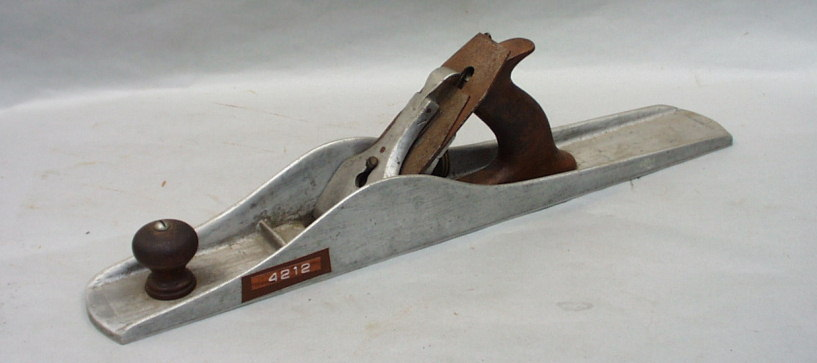

In [ ]:
from datasets import load_dataset

# We use streaming=True to avoid downloading 100+ GB of data!
print("Connecting to ImageNet-1k...")
dataset = load_dataset("imagenet-1k", split="train", streaming=True, trust_remote_code=True)
print(type(dataset))

# Look at the very first image in the dataset
iterator = iter(dataset)
first_sample = next(iterator)

print("\nDataset Labels:", first_sample['label'])
first_sample['image']

In [ ]:
from PIL import Image
import requests

from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests

# 1. Load the model and the processor (which prepares our images/text for the model)
model_id = "openai/clip-vit-base-patch32"
### STUDENT CODE HERE ###
clip_model.to(device)

# 2. Get a sample image from the internet
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# 3. Give the model some text options to guess what is in the image
text_options = ["a photo of a cat", "a photo of a dog", "a photo of a car"]

# 4. Process the inputs and run the model!
inputs = processor(text=text_options, images=image, return_tensors="pt", padding=True)
inputs = inputs.to(device)

outputs = clip_model(**inputs)

# 5. Look at the results
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

print("Probability it is a cat:", probs[0][0].item())
print("Probability it is a dog:", probs[0][1].item())
print("Probability it is a car:", probs[0][2].item())

Probability it is a cat: 0.9926018118858337
Probability it is a dog: 0.005142036825418472
Probability it is a car: 0.002256136853247881


In [ ]:
from torchvision import transforms

# ResNet requires images to be resized and normalized in a very specific way
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Process the image and move it to the GPU
input_tensor = preprocess(image).unsqueeze(0)
print(input_tensor.shape)  # Should be [1, 3, 224, 224]

# Run the model
with torch.inference_mode():
    model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
    output = model(input_tensor)
print(output.shape) # Should be [1, 1000]

# Get the highest predicted score
predicted_class = output.argmax(dim=1).item()
print(f"ResNet predicts this is class ID: {predicted_class}")

torch.Size([1, 3, 224, 224])


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


torch.Size([1, 1000])
ResNet predicts this is class ID: 463


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

prompt = "Give me a short introduction to large language model."
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
response

'A Large Language Model (LLM) is a type of artificial intelligence that can generate human-like text based on the input it receives. LLMs are designed to understand and respond to natural language inputs in a way that mimics human conversation or writing.\n\nThese models use deep learning techniques such as neural networks to process vast amounts of data and learn patterns and relationships between words and phrases. They can be trained on large datasets containing billions of words from books, articles, web pages, and other sources of text.\n\nThe ability of an LLM to generate coherent and contextually appropriate responses makes them useful for a wide range of applications, including:\n\n1. Content creation: generating news articles, blog posts, social media content, and more.\n2. Chatbots: creating conversational AI assistants that can answer customer queries and provide support.\n3. Translation: translating text from one language to another with high accuracy.\n4. Question answerin

In [ ]:
# pip install accelerate
import requests
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration

processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", device_map="auto")

img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

question = "how many dogs are in the picture?"
inputs = processor(raw_image, question, return_tensors="pt").to("cuda")

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True).strip())


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


how many dogs are in the picture?
